ETAPA 1

Importando as bibliotecas

In [1]:
# Importando tudo que vamos usar nesse projeto!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais — deixa os gráficos maiores e mais bonitos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


Vamos usar um dataset real de imóveis para aluguel no Brasil, disponível publicamente:

In [9]:
df = pd.read_csv(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\data\raw\houses_to_rent.csv')

print(f"Dataset carregado! {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dataset carregado! 6080 linhas e 14 colunas.


,Unnamed: 0,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa,rent amount,property tax,fire insurance,total
0,0,1,240,3,3,4,-,acept,furnished,R$0,"R$8,000","R$1,000",R$121,"R$9,121"
1,1,0,64,2,1,1,10,acept,not furnished,R$540,R$820,R$122,R$11,"R$1,493"
2,2,1,443,5,5,4,3,acept,furnished,"R$4,172","R$7,000","R$1,417",R$89,"R$12,680"
3,3,1,73,2,2,1,12,acept,not furnished,R$700,"R$1,250",R$150,R$16,"R$2,116"
4,4,1,19,1,1,0,-,not acept,not furnished,R$0,"R$1,200",R$41,R$16,"R$1,257"


Primeira olhada nos dados:

In [10]:
# .head() mostra as 5 primeiras linhas
# Sempre o primeiro passo — ver como os dados se parecem
df.head()

,Unnamed: 0,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa,rent amount,property tax,fire insurance,total
0,0,1,240,3,3,4,-,acept,furnished,R$0,"R$8,000","R$1,000",R$121,"R$9,121"
1,1,0,64,2,1,1,10,acept,not furnished,R$540,R$820,R$122,R$11,"R$1,493"
2,2,1,443,5,5,4,3,acept,furnished,"R$4,172","R$7,000","R$1,417",R$89,"R$12,680"
3,3,1,73,2,2,1,12,acept,not furnished,R$700,"R$1,250",R$150,R$16,"R$2,116"
4,4,1,19,1,1,0,-,not acept,not furnished,R$0,"R$1,200",R$41,R$16,"R$1,257"


Entendendo a estrutura:

In [11]:
# .info() mostra: nome das colunas, tipo de dado e se tem valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6080 entries, 0 to 6079
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      6080 non-null   int64 
 1   city            6080 non-null   int64 
 2   area            6080 non-null   int64 
 3   rooms           6080 non-null   int64 
 4   bathroom        6080 non-null   int64 
 5   parking spaces  6080 non-null   int64 
 6   floor           6080 non-null   object
 7   animal          6080 non-null   object
 8   furniture       6080 non-null   object
 9   hoa             6080 non-null   object
 10  rent amount     6080 non-null   object
 11  property tax    6080 non-null   object
 12  fire insurance  6080 non-null   object
 13  total           6080 non-null   object
dtypes: int64(6), object(8)
memory usage: 665.1+ KB


Estatísticas gerais:

In [12]:
# .describe() mostra média, mínimo, máximo, desvio padrão de cada coluna numérica
# Ótimo para detectar outliers logo de cara
df.describe()

,Unnamed: 0,city,area,rooms,bathroom,parking spaces
count,6080.00000,6080.000000,6080.000000,6080.000000,6080.000000,6080.000000
mean,3039.50000,0.863322,151.143914,2.492599,2.341612,1.756250
std,1755.28915,0.343535,375.559485,1.129665,1.438860,1.611909
min,0.00000,0.000000,10.000000,1.000000,1.000000,0.000000
25%,1519.75000,1.000000,58.000000,2.000000,1.000000,1.000000
50%,3039.50000,1.000000,100.000000,3.000000,2.000000,1.000000
75%,4559.25000,1.000000,200.000000,3.000000,3.000000,2.000000
max,6079.00000,1.000000,24606.000000,10.000000,10.000000,12.000000


--------


ETAPA 2 - Limpeza de dados

Remover colunas inuteis

In [13]:
# Unnamed: 0 é só um índice duplicado, não agrega nada
df = df.drop(columns=['Unnamed: 0'])

print("Coluna removida!")
print(df.columns.tolist())

Coluna removida!
['city', 'area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'animal', 'furniture', 'hoa', 'rent amount', 'property tax', 'fire insurance', 'total']


 Corrigindo a coluna city: (não há como comparar cidades chamadas de 0 e 1).

In [14]:
# 0 = São Paulo, 1 = Rio de Janeiro (descoberto na documentação do dataset)
df['city'] = df['city'].map({0: 'São Paulo', 1: 'Rio de Janeiro'})

print(df['city'].value_counts())

city
Rio de Janeiro    5249
São Paulo          831
Name: count, dtype: int64


Corrigindo a coluna floor:

In [15]:
# O traço "-" significa térreo/sem andar — vamos trocar por 0
df['floor'] = df['floor'].replace('-', '0')
df['floor'] = pd.to_numeric(df['floor'], errors='coerce')

print(f"Valores nulos em floor: {df['floor'].isnull().sum()}")
print(df['floor'].describe())

Valores nulos em floor: 0
count    6080.000000
mean        5.672204
std         6.168918
min         0.000000
25%         0.000000
50%         4.000000
75%         9.000000
max        99.000000
Name: floor, dtype: float64


Convertendo colunas de valor para número:

In [16]:
# Essas colunas têm "R$" e "," que impedem cálculos
# Vamos limpar e converter para float
colunas_valor = ['hoa', 'rent amount', 'property tax', 'fire insurance', 'total']

for col in colunas_valor:
    df[col] = df[col].str.replace('R$', '', regex=False)  # remove R$
    df[col] = df[col].str.replace(',', '', regex=False)    # remove vírgulas
    df[col] = pd.to_numeric(df[col], errors='coerce')      # converte para número

print("Conversão concluída!")
df[colunas_valor].head()

Conversão concluída!


,hoa,rent amount,property tax,fire insurance,total
0,0.0,8000,1000.0,121,9121
1,540.0,820,122.0,11,1493
2,4172.0,7000,1417.0,89,12680
3,700.0,1250,150.0,16,2116
4,0.0,1200,41.0,16,1257


Verificando o resultado final:

In [17]:
# Confere se tudo ficou correto
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6080 entries, 0 to 6079
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            6080 non-null   object 
 1   area            6080 non-null   int64  
 2   rooms           6080 non-null   int64  
 3   bathroom        6080 non-null   int64  
 4   parking spaces  6080 non-null   int64  
 5   floor           6080 non-null   int64  
 6   animal          6080 non-null   object 
 7   furniture       6080 non-null   object 
 8   hoa             5878 non-null   float64
 9   rent amount     6080 non-null   int64  
 10  property tax    6053 non-null   float64
 11  fire insurance  6080 non-null   int64  
 12  total           6080 non-null   int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 617.6+ KB


Limpeza funcionou corretamente!
Podemos ver as notaveis diferenças: Todas as colunas de valor viraram número (int64 e float64), city virou texto legível e floor foi corrigido.
Reparem que hoa tem 202 nulos (6080 - 5878) e property tax tem 27 nulos — vamos tratar isso agora.

Tratando os valores nulos:

In [18]:
# hoa (condomínio) nulo provavelmente significa R$0 — imóvel sem condomínio
df['hoa'] = df['hoa'].fillna(0)

# property tax nulo também tratamos como 0
df['property tax'] = df['property tax'].fillna(0)

print(f"Nulos restantes:\n{df.isnull().sum()}")

Nulos restantes:
city              0
area              0
rooms             0
bathroom          0
parking spaces    0
floor             0
animal            0
furniture         0
hoa               0
rent amount       0
property tax      0
fire insurance    0
total             0
dtype: int64


Renomeando colunas para português: (projeto em Português)

In [19]:
# Deixa o projeto mais profissional e fácil de entender
df = df.rename(columns={
    'city':           'cidade',
    'area':           'area_m2',
    'rooms':          'quartos',
    'bathroom':       'banheiros',
    'parking spaces': 'vagas',
    'floor':          'andar',
    'animal':         'aceita_animal',
    'furniture':      'mobiliado',
    'hoa':            'condominio',
    'rent amount':    'aluguel',
    'property tax':   'iptu',
    'fire insurance': 'seguro_incendio',
    'total':          'total'
})

df.head()

,cidade,area_m2,quartos,banheiros,vagas,andar,aceita_animal,mobiliado,condominio,aluguel,iptu,seguro_incendio,total
0,Rio de Janeiro,240,3,3,4,0,acept,furnished,0.0,8000,1000.0,121,9121
1,São Paulo,64,2,1,1,10,acept,not furnished,540.0,820,122.0,11,1493
2,Rio de Janeiro,443,5,5,4,3,acept,furnished,4172.0,7000,1417.0,89,12680
3,Rio de Janeiro,73,2,2,1,12,acept,not furnished,700.0,1250,150.0,16,2116
4,Rio de Janeiro,19,1,1,0,0,not acept,not furnished,0.0,1200,41.0,16,1257


Salvando o dataset limpo:

In [20]:
# Salvamos na pasta processed — esse é o arquivo que vamos usar nas análises
df.to_csv(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\data\processed\imoveis_limpo.csv', index=False)

print("Dataset limpo salvo com sucesso!")
print(f"Shape final: {df.shape}")

Dataset limpo salvo com sucesso!
Shape final: (6080, 13)


----------

Etapa 3 — Análises e Visualizações, Vamos responder perguntas reais sobre o mercado imobiliário. 

Distribuição de imóveis por cidade:

C:\Users\Alan\AppData\Local\Temp\ipykernel_7176\614626891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cidade', palette=['#2196F3', '#4CAF50'])


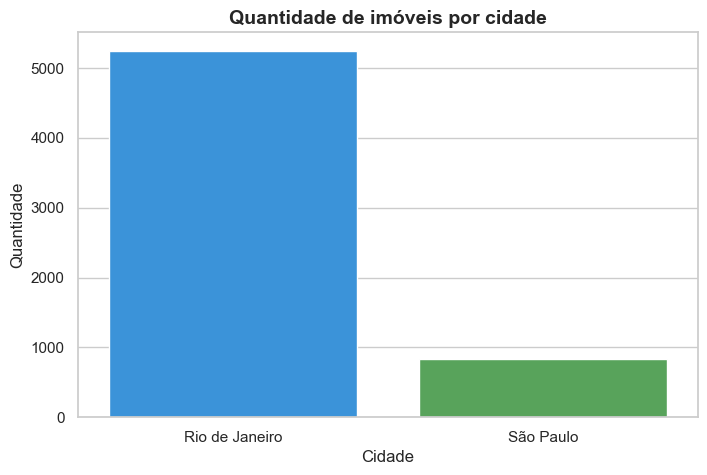

Gráfico salvo!


In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cidade', palette=['#2196F3', '#4CAF50'])
plt.title('Quantidade de imóveis por cidade', fontsize=14, fontweight='bold')
plt.xlabel('Cidade')
plt.ylabel('Quantidade')
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\01_imoveis_por_cidade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

------

Qual cidade tem o aluguel mais caro em média?

Média de aluguel por cidade:
cidade
Rio de Janeiro    R$ 4,695.00
São Paulo         R$ 2,506.21
Name: aluguel, dtype: object


C:\Users\Alan\AppData\Local\Temp\ipykernel_7176\674378860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_aluguel.index, y=media_aluguel.values, palette=['#2196F3', '#4CAF50'])


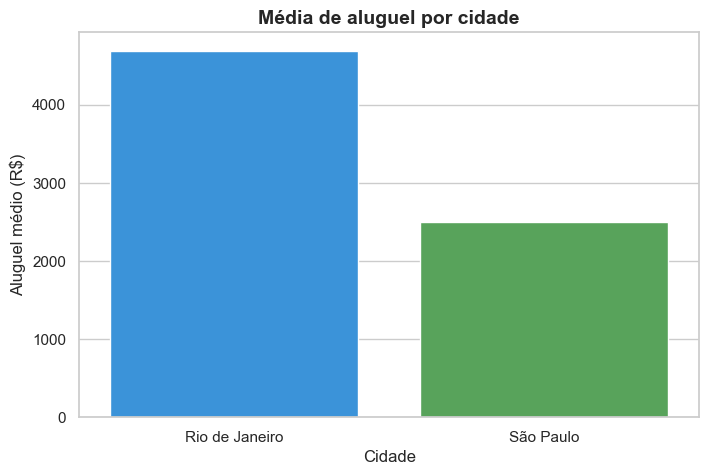

In [22]:
media_aluguel = df.groupby('cidade')['aluguel'].mean().sort_values(ascending=False)
print("Média de aluguel por cidade:")
print(media_aluguel.apply(lambda x: f'R$ {x:,.2f}'))

plt.figure(figsize=(8, 5))
sns.barplot(x=media_aluguel.index, y=media_aluguel.values, palette=['#2196F3', '#4CAF50'])
plt.title('Média de aluguel por cidade', fontsize=14, fontweight='bold')
plt.xlabel('Cidade')
plt.ylabel('Aluguel médio (R$)')
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\02_media_aluguel_cidade.png', dpi=150, bbox_inches='tight')
plt.show()

--------

 Aluguel sobe conforme o número de quartos?

Média de aluguel por número de quartos:
quartos
1     R$ 2,315.00
2     R$ 2,988.73
3     R$ 5,045.17
4     R$ 7,911.23
5     R$ 8,891.29
6     R$ 7,285.91
7     R$ 8,590.00
8     R$ 8,666.67
10    R$ 9,615.00
Name: aluguel, dtype: object


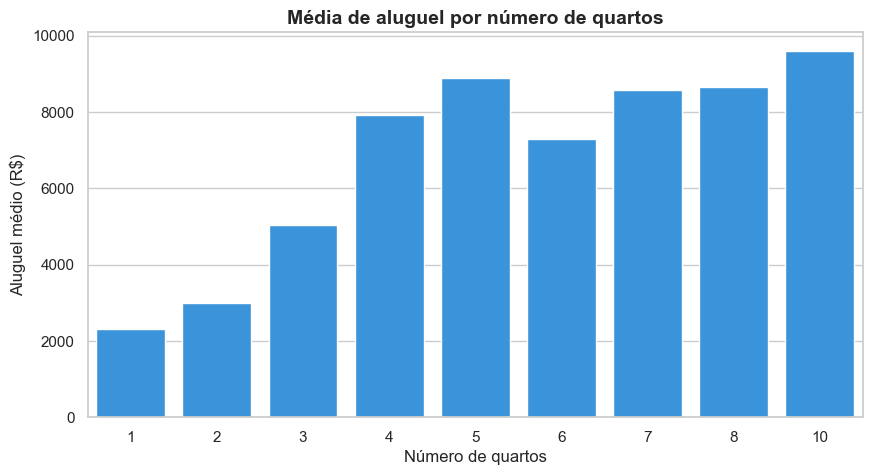

In [23]:
media_quartos = df.groupby('quartos')['aluguel'].mean()
print("Média de aluguel por número de quartos:")
print(media_quartos.apply(lambda x: f'R$ {x:,.2f}'))

plt.figure(figsize=(10, 5))
sns.barplot(x=media_quartos.index, y=media_quartos.values, color='#2196F3')
plt.title('Média de aluguel por número de quartos', fontsize=14, fontweight='bold')
plt.xlabel('Número de quartos')
plt.ylabel('Aluguel médio (R$)')
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\03_aluguel_por_quartos.png', dpi=150, bbox_inches='tight')
plt.show()

--------


Área vs Aluguel: existe correlação?

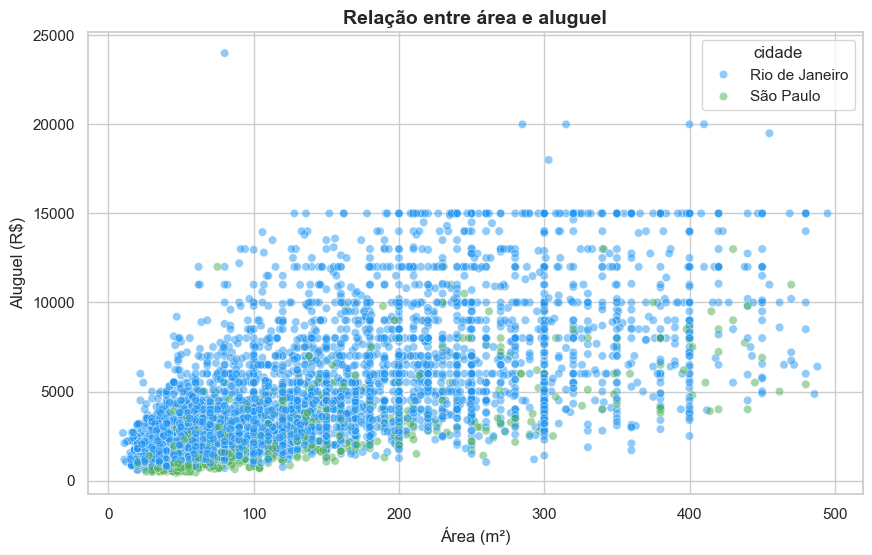

In [24]:
# Removemos outliers extremos para o gráfico ficar mais legível
df_filtrado = df[df['area_m2'] < 500]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtrado, x='area_m2', y='aluguel', hue='cidade', alpha=0.5, palette=['#2196F3', '#4CAF50'])
plt.title('Relação entre área e aluguel', fontsize=14, fontweight='bold')
plt.xlabel('Área (m²)')
plt.ylabel('Aluguel (R$)')
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\04_area_vs_aluguel.png', dpi=150, bbox_inches='tight')
plt.show()

-----

Imóveis que aceitam animais são mais caros?

C:\Users\Alan\AppData\Local\Temp\ipykernel_7176\2878125382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='aceita_animal', y='aluguel', palette=['#FF7043', '#42A5F5'])


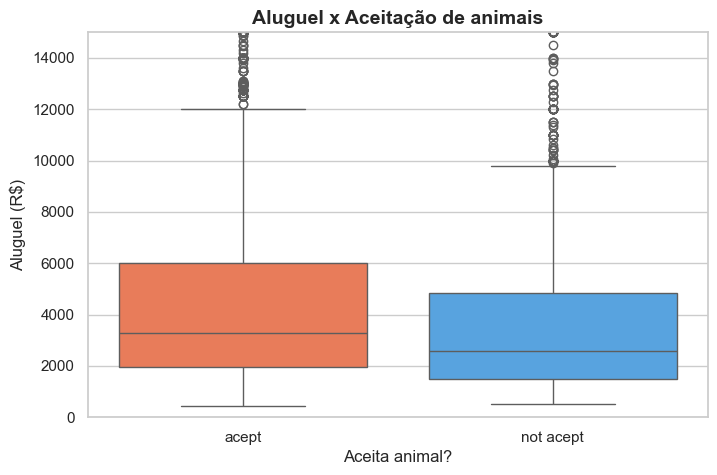

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='aceita_animal', y='aluguel', palette=['#FF7043', '#42A5F5'])
plt.title('Aluguel x Aceitação de animais', fontsize=14, fontweight='bold')
plt.xlabel('Aceita animal?')
plt.ylabel('Aluguel (R$)')
plt.ylim(0, 15000)
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\05_animal_vs_aluguel.png', dpi=150, bbox_inches='tight')
plt.show()

------

 Mapa de correlação entre variáveis:

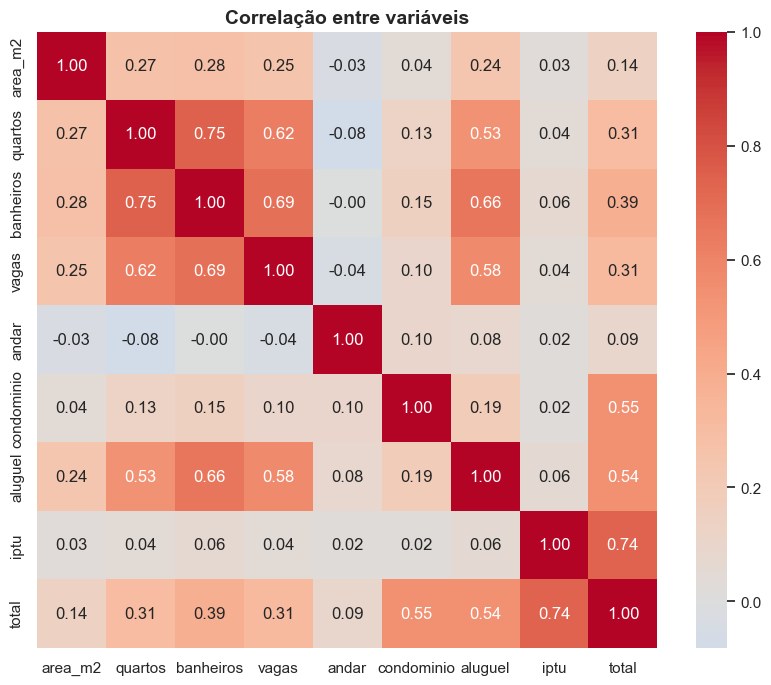

In [26]:
# Correlação mostra quais variáveis influenciam mais o aluguel
colunas_numericas = ['area_m2', 'quartos', 'banheiros', 'vagas', 'andar', 'condominio', 'aluguel', 'iptu', 'total']

plt.figure(figsize=(10, 8))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis', fontsize=14, fontweight='bold')
plt.savefig(r'C:\Users\Alan\imoveis-brasil-eda\imoveis-brasil-eda\outputs\graficos\06_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

------

In [27]:
print("=" * 55)
print("   RESUMO DA ANÁLISE — MERCADO IMOBILIÁRIO BRASIL")
print("=" * 55)

print(f"\n Total de imóveis analisados : {len(df):,}")
print(f" Cidades                     : {df['cidade'].nunique()}")

print(f"\n--- Aluguéis ---")
print(f" Menor aluguel   : R$ {df['aluguel'].min():,.0f}")
print(f" Maior aluguel   : R$ {df['aluguel'].max():,.0f}")
print(f" Média geral     : R$ {df['aluguel'].mean():,.0f}")
print(f" Mediana         : R$ {df['aluguel'].median():,.0f}")

print(f"\n--- Por cidade ---")
for cidade, grupo in df.groupby('cidade'):
    print(f" {cidade:15s} → média R$ {grupo['aluguel'].mean():,.0f} | {len(grupo):,} imóveis")

print(f"\n--- Correlações com aluguel ---")
corr = df[['area_m2','quartos','banheiros','vagas','aluguel']].corr()['aluguel'].drop('aluguel').sort_values(ascending=False)
for var, val in corr.items():
    print(f" {var:15s} → {val:.2f}")

print(f"\n--- Pet friendly ---")
for animal, grupo in df.groupby('aceita_animal'):
    print(f" {animal:12s} → média R$ {grupo['aluguel'].mean():,.0f}")

print("\n" + "=" * 55)

   RESUMO DA ANÁLISE — MERCADO IMOBILIÁRIO BRASIL

 Total de imóveis analisados : 6,080
 Cidades                     : 2

--- Aluguéis ---
 Menor aluguel   : R$ 420
 Maior aluguel   : R$ 45,000
 Média geral     : R$ 4,396
 Mediana         : R$ 3,111

--- Por cidade ---
 Rio de Janeiro  → média R$ 4,695 | 5,249 imóveis
 São Paulo       → média R$ 2,506 | 831 imóveis

--- Correlações com aluguel ---
 banheiros       → 0.66
 vagas           → 0.58
 quartos         → 0.53
 area_m2         → 0.24

--- Pet friendly ---
 acept        → média R$ 4,586
 not acept    → média R$ 3,769

